In [1]:
# Dependencies and Setup
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Hide warning messages in notebook
import warnings
warnings.filterwarnings('ignore')

# File to Load (Remember to Change These)
mouse_drug_data_to_load = "data/mouse_drug_data.csv"
clinical_trial_data_to_load = "data/clinicaltrial_data.csv"

# Read the Mouse and Drug Data and the Clinical Trial Data
mouse_drug_data = pd.read_csv(mouse_drug_data_to_load)
clinical_trial_data_to_load_data=pd.read_csv(clinical_trial_data_to_load)

# Combine the data into a single dataset
pymaceutical_data_complete = pd.merge(clinical_trial_data_to_load_data,mouse_drug_data,how = "left", on=["Mouse ID"])

# Display the data table for preview
pymaceutical_data_complete.head()


,Mouse ID,Timepoint,Tumor Volume (mm3),Metastatic Sites,Drug
0,b128,0,45.0,0,Capomulin
1,f932,0,45.0,0,Ketapril
2,g107,0,45.0,0,Ketapril
3,a457,0,45.0,0,Ketapril
4,c819,0,45.0,0,Ketapril


## Tumor Response to Treatment

In [2]:
# Store the Mean Tumor Volume Data Grouped by Drug and Timepoint 
drug_timep_df = pymaceutical_data_complete.groupby(['Drug','Timepoint'])

drug_timep_mean=drug_timep_df["Tumor Volume (mm3)"].mean()

# Convert to DataFrame
drug_timep_mean_df = drug_timep_mean.reset_index()


# Preview DataFrame
drug_timep_mean_df

,Drug,Timepoint,Tumor Volume (mm3)
0,Capomulin,0,45.000000
1,Capomulin,5,44.266086
2,Capomulin,10,43.084291
3,Capomulin,15,42.064317
4,Capomulin,20,40.716325
...,...,...,...
95,Zoniferol,25,55.432935
96,Zoniferol,30,57.713531
97,Zoniferol,35,60.089372
98,Zoniferol,40,62.916692


In [3]:
# Store the Standard Error of Tumor Volumes Grouped by Drug and Timepoint
drug_timep_df = pymaceutical_data_complete.groupby(['Drug','Timepoint'])

drug_timep_error=drug_timep_df["Tumor Volume (mm3)"].sem()

# Convert to DataFrame
drug_timep_error_df = drug_timep_error.reset_index()
# Preview DataFrame
drug_timep_error_df.head()


,Drug,Timepoint,Tumor Volume (mm3)
0,Capomulin,0,0.000000
1,Capomulin,5,0.448593
2,Capomulin,10,0.702684
3,Capomulin,15,0.838617
4,Capomulin,20,0.909731


In [4]:
# Minor Data Munging to Re-Format the Data Frames
drug_timep_mean_reshape_df = drug_timep_mean_df.pivot(index ='Timepoint', columns = 'Drug', values ='Tumor Volume (mm3)')

# Preview that Reformatting worked
drug_timep_mean_reshape_df.head()

Drug,Capomulin,Ceftamin,Infubinol,Ketapril,Naftisol,Placebo,Propriva,Ramicane,Stelasyn,Zoniferol
Timepoint,,,,,,,,,,
0,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000
5,44.266086,46.503051,47.062001,47.389175,46.796098,47.125589,47.248967,43.944859,47.527452,46.851818
10,43.084291,48.285125,49.403909,49.582269,48.694210,49.423329,49.101541,42.531957,49.463844,48.689881
15,42.064317,50.094055,51.296397,52.399974,50.933018,51.359742,51.067318,41.495061,51.529409,50.779059
20,40.716325,52.157049,53.197691,54.920935,53.644087,54.364417,53.346737,40.238325,54.067395,53.170334


In [5]:
# Minor Data Munging to Re-Format the Data Frames
drug_timep_error_reshape_df = drug_timep_error_df.pivot(index ='Timepoint', columns = 'Drug', values ='Tumor Volume (mm3)')

# Preview that Reformatting worked
drug_timep_error_reshape_df.head()

Drug,Capomulin,Ceftamin,Infubinol,Ketapril,Naftisol,Placebo,Propriva,Ramicane,Stelasyn,Zoniferol
Timepoint,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.448593,0.164505,0.235102,0.264819,0.202385,0.218091,0.231708,0.482955,0.239862,0.188950
10,0.702684,0.236144,0.282346,0.357421,0.319415,0.402064,0.376195,0.720225,0.433678,0.263949
15,0.838617,0.332053,0.357705,0.580268,0.444378,0.614461,0.466109,0.770432,0.493261,0.370544
20,0.909731,0.359482,0.476210,0.726484,0.595260,0.839609,0.555181,0.786199,0.621889,0.533182


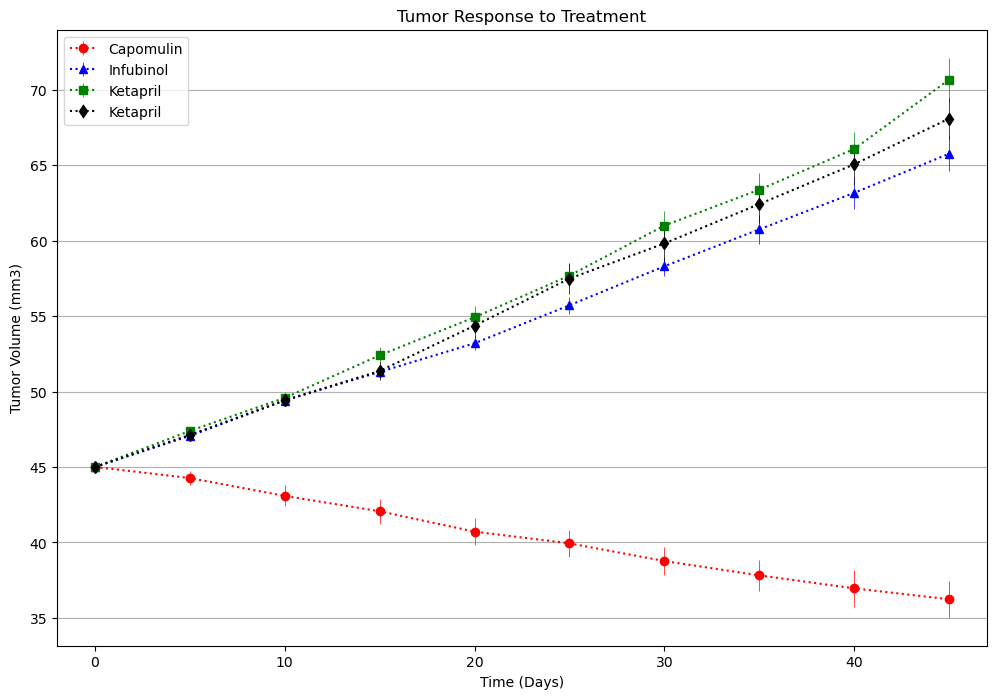

In [6]:
# Generate the Plot (with Error Bars)
# drug_timep_mean_reshape_df.columns.name=None
# markers=['o--','^-.','s-','4-','+-','d-','--','*-','h-','D-']
# ax=drug_timep_mean_reshape_df.plot(kind='line',figsize=(12,8),yerr = drug_timep_error_reshape_df,legend=False)
# # # #ax.set_prop_cycle(None)
# drug_timep_mean_reshape_df.plot(figsize=(14,8),style=markers,legend=True,ax=ax)
# Capomulin, Infubinol, Ketapril, and Placebo
x_axis = drug_timep_mean_reshape_df.index
fig, ax=plt.subplots(figsize=(12,8))

ax.errorbar(x_axis,drug_timep_mean_reshape_df["Capomulin"], drug_timep_error_reshape_df["Capomulin"],linestyle=":",fmt="ro",elinewidth=0.5,label="Capomulin")
ax.errorbar(x_axis,drug_timep_mean_reshape_df["Infubinol"], drug_timep_error_reshape_df["Infubinol"],linestyle=":",fmt="b^",elinewidth=0.5,label="Infubinol")
ax.errorbar(x_axis,drug_timep_mean_reshape_df["Ketapril"], drug_timep_error_reshape_df["Ketapril"],linestyle=":",fmt="gs",elinewidth=0.5,label="Ketapril")
ax.errorbar(x_axis,drug_timep_mean_reshape_df["Placebo"], drug_timep_error_reshape_df["Placebo"],linestyle=":",fmt="kd",elinewidth=0.5,label="Ketapril")
ax.grid(axis='y')

ax.set_title("Tumor Response to Treatment")   
ax.set_xlabel("Time (Days)")
ax.set_ylabel("Tumor Volume (mm3)")
ax.legend(loc="upper left")

plt.xlim(min(drug_timep_mean_reshape_df.index)-2,max(drug_timep_mean_reshape_df.index)+2)

# Save the Figure
plt.savefig("Tumor Response to Treatment.png")

In [7]:
# Show the Figure
plt.show()

![Tumor Response to Treatment](../Images/treatment.png)

## Metastatic Response to Treatment

In [8]:
# Store the Mean Met. Site Data Grouped by Drug and Timepoint 
mr_mean = pymaceutical_data_complete.groupby(['Drug','Timepoint'])["Metastatic Sites"].mean()

# Convert to DataFrame
#mr_mean_df =mr_mean.reset_index()
mr_mean_df=pd.DataFrame(mr_mean)
# Preview DataFrame
mr_mean_df.head()

Metastatic Sites
Drug      Timepoint                  
Capomulin 0                  0.000000
          5                  0.160000
          10                 0.320000
          15                 0.375000
          20                 0.652174

In [9]:
# Store the Standard Error associated with Met. Sites Grouped by Drug and Timepoint 
mr_error = pymaceutical_data_complete.groupby(['Drug','Timepoint'])["Metastatic Sites"].sem()
# Convert to DataFrame
#mr_error_df =mr_error.reset_index()
# Preview DataFrame
#mr_error_df.head()
mr_error_df=pd.DataFrame(mr_error)
mr_error_df.head()

Metastatic Sites
Drug      Timepoint                  
Capomulin 0                  0.000000
          5                  0.074833
          10                 0.125433
          15                 0.132048
          20                 0.161621

In [10]:
# Minor Data Munging to Re-Format the Data Frames
mr_mean_reshape_df = mr_mean_df.pivot_table(index ='Timepoint', columns = 'Drug', values ='Metastatic Sites')
# Preview that Reformatting worked
mr_mean_reshape_df.head()

Drug,Capomulin,Ceftamin,Infubinol,Ketapril,Naftisol,Placebo,Propriva,Ramicane,Stelasyn,Zoniferol
Timepoint,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.160000,0.380952,0.280000,0.304348,0.260870,0.375000,0.320000,0.120000,0.240000,0.166667
10,0.320000,0.600000,0.666667,0.590909,0.523810,0.833333,0.565217,0.250000,0.478261,0.500000
15,0.375000,0.789474,0.904762,0.842105,0.857143,1.250000,0.764706,0.333333,0.782609,0.809524
20,0.652174,1.111111,1.050000,1.210526,1.150000,1.526316,1.000000,0.347826,0.952381,1.294118


In [11]:
# Minor Data Munging to Re-Format the Data Frames
mr_error_reshape_df = mr_error_df.pivot_table(index ='Timepoint', columns = 'Drug', values ='Metastatic Sites')
# Preview that Reformatting worked
mr_error_reshape_df.head()

Drug,Capomulin,Ceftamin,Infubinol,Ketapril,Naftisol,Placebo,Propriva,Ramicane,Stelasyn,Zoniferol
Timepoint,,,,,,,,,,
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,0.074833,0.108588,0.091652,0.098100,0.093618,0.100947,0.095219,0.066332,0.087178,0.077709
10,0.125433,0.152177,0.159364,0.142018,0.163577,0.115261,0.105690,0.090289,0.123672,0.109109
15,0.132048,0.180625,0.194015,0.191381,0.158651,0.190221,0.136377,0.115261,0.153439,0.111677
20,0.161621,0.241034,0.234801,0.236680,0.181731,0.234064,0.171499,0.119430,0.200905,0.166378


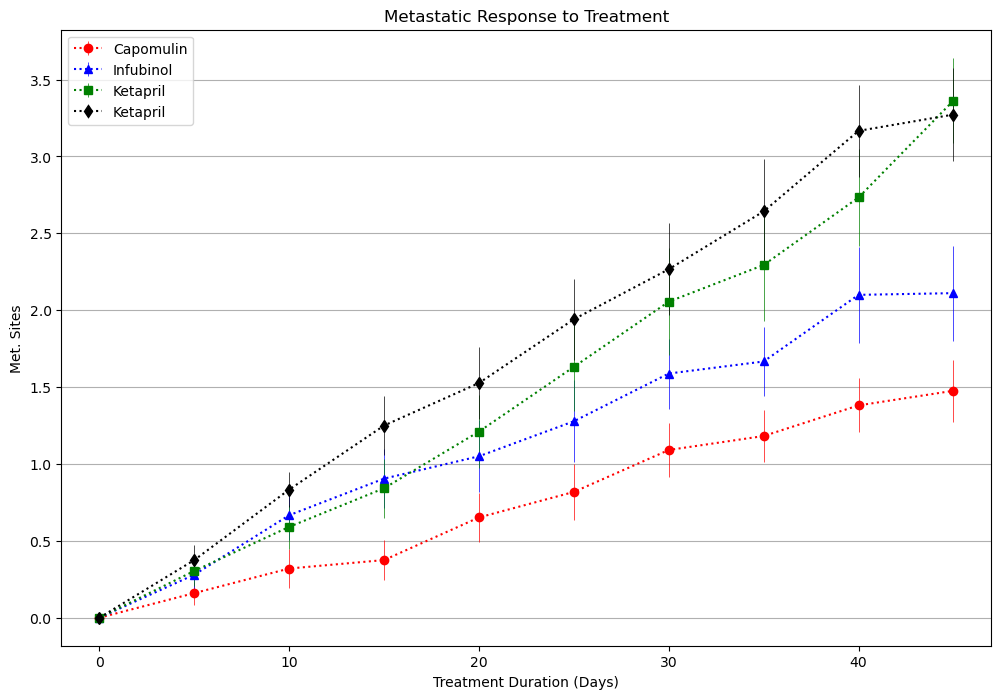

In [12]:
# Generate the Plot (with Error Bars)

x_axis = mr_mean_reshape_df.index
fig, ax=plt.subplots(figsize=(12,8))

ax.errorbar(x_axis,mr_mean_reshape_df["Capomulin"], mr_error_reshape_df["Capomulin"],linestyle=":",fmt="ro",elinewidth=0.5,label="Capomulin")
ax.errorbar(x_axis,mr_mean_reshape_df["Infubinol"], mr_error_reshape_df["Infubinol"],linestyle=":",fmt="b^",elinewidth=0.5,label="Infubinol")
ax.errorbar(x_axis,mr_mean_reshape_df["Ketapril"], mr_error_reshape_df["Ketapril"],linestyle=":",fmt="gs",elinewidth=0.5,label="Ketapril")
ax.errorbar(x_axis,mr_mean_reshape_df["Placebo"], mr_error_reshape_df["Placebo"],linestyle=":",fmt="kd",elinewidth=0.5,label="Ketapril")
ax.grid(axis='y')
ax.set_title("Metastatic Response to Treatment")   
ax.set_xlabel("Treatment Duration (Days)")
ax.set_ylabel("Met. Sites")
ax.legend(loc="upper left")
plt.xlim(min(drug_timep_mean_reshape_df.index)-2,max(drug_timep_mean_reshape_df.index)+2)

# Save the Figure
plt.savefig("Metastatic Response to Treatment.png")


In [13]:
# Show the Figure
plt.show()

![Metastatic Spread During Treatment](../Images/spread.png)

## Survival Rates

In [14]:
# Store the Count of Mice Grouped by Drug and Timepoint (W can pass any metric)
mg_count = pymaceutical_data_complete.groupby(['Drug','Timepoint'])["Mouse ID"].count()

# Convert to DataFrame
mg_count_df = mg_count.reset_index()
# Preview DataFrame
mg_count_df.head()

,Drug,Timepoint,Mouse ID
0,Capomulin,0,25
1,Capomulin,5,25
2,Capomulin,10,25
3,Capomulin,15,24
4,Capomulin,20,23


In [15]:
# Minor Data Munging to Re-Format the Data Frames
mg_count_reshape_df = mg_count_df.pivot(index ='Timepoint', columns = 'Drug', values ='Mouse ID')
# Preview the Data Frame
mg_count_reshape_df.head()

Drug,Capomulin,Ceftamin,Infubinol,Ketapril,Naftisol,Placebo,Propriva,Ramicane,Stelasyn,Zoniferol
Timepoint,,,,,,,,,,
0,25,25,25,25,25,25,26,25,26,25
5,25,21,25,23,23,24,25,25,25,24
10,25,20,21,22,21,24,23,24,23,22
15,24,19,21,19,21,20,17,24,23,21
20,23,18,20,19,20,19,17,23,21,17


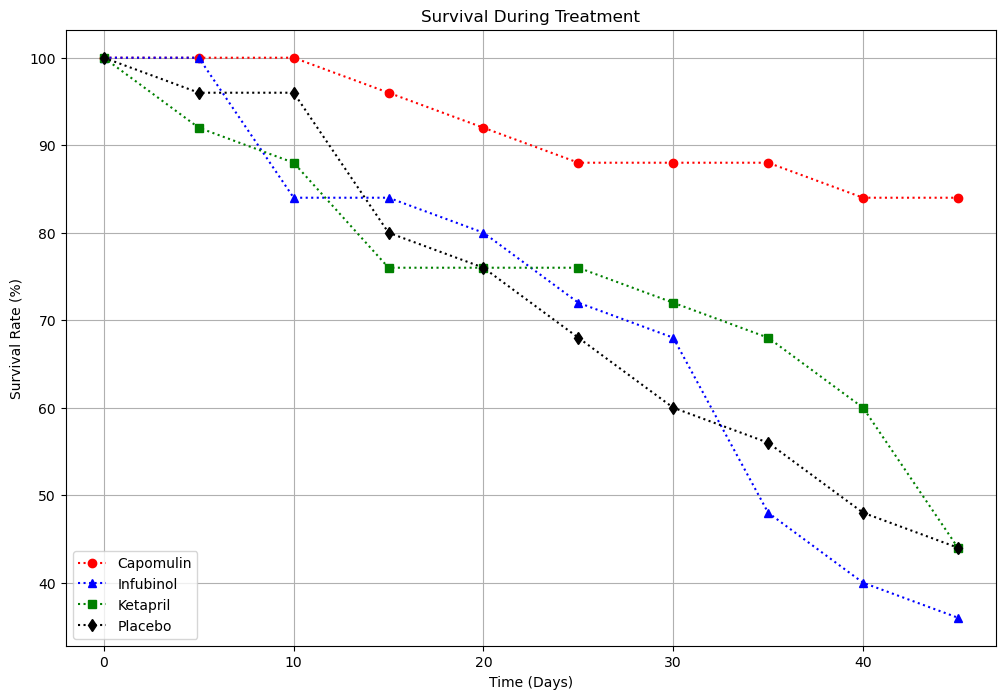

In [16]:
# calculate percentage
mg_count_percent_df = mg_count_reshape_df/mg_count_reshape_df.iloc[0]*100
# Generate the Plot (Accounting for percentages)
x_axis = mr_mean_reshape_df.index
plt.figure(figsize=(12,8))
plt.plot(x_axis,mg_count_percent_df["Capomulin"],linestyle=":",marker="o",color="red",label="Capomulin")
plt.plot(x_axis,mg_count_percent_df["Infubinol"],linestyle=":",marker="^",color="blue",label="Infubinol")
plt.plot(x_axis,mg_count_percent_df["Ketapril"],linestyle=":",marker="s",color="green",label="Ketapril")
plt.plot(x_axis,mg_count_percent_df["Placebo"],linestyle=":",marker="d",color="black",label="Placebo")
plt.grid()
plt.title("Survival During Treatment")   
plt.xlabel("Time (Days)")
plt.ylabel("Survival Rate (%)")
plt.legend(loc="lower left")
plt.xlim(min(drug_timep_mean_reshape_df.index)-2,max(drug_timep_mean_reshape_df.index)+2)

# Save the Figure
plt.savefig("Survival During Treatment.png")

# Show the Figure
plt.show()

![Metastatic Spread During Treatment](../Images/survival.png)

## Summary Bar Graph

In [17]:
# Calculate the percent changes for each drug

pc_change=(drug_timep_mean_reshape_df.iloc[-1]-drug_timep_mean_reshape_df.iloc[0])/drug_timep_mean_reshape_df.iloc[0]*100

# Display the data to confirm
pc_change


Drug
Capomulin   -19.475303
Ceftamin     42.516492
Infubinol    46.123472
Ketapril     57.028795
Naftisol     53.923347
Placebo      51.297960
Propriva     47.241175
Ramicane    -22.320900
Stelasyn     52.085134
Zoniferol    46.579751
dtype: float64

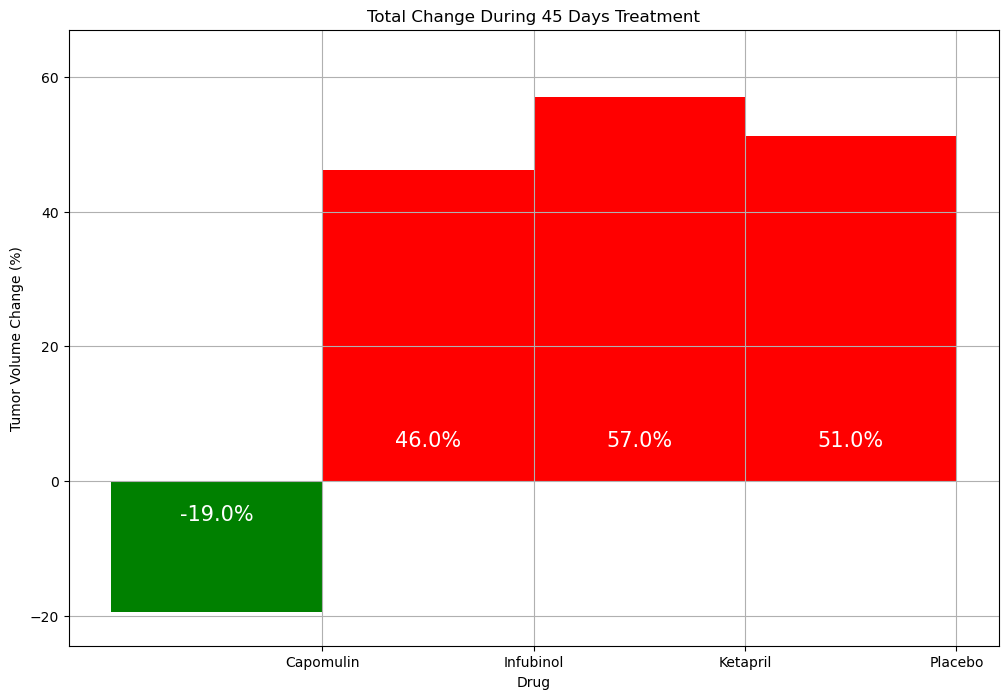

In [18]:
# Store all Relevant Percent Changes into a Tuple
drug_change_ss = pc_change[["Capomulin","Infubinol","Ketapril","Placebo"]]
drug_change_select = list(zip(drug_change_ss.index,drug_change_ss))

# Splice the data between passing and failing drugs
drugs = [item[0] for item in drug_change_select]
bars_in_drugs =[item[1] for item in drug_change_select]
x_axis = np.arange(len(bars_in_drugs))
fig, ax=plt.subplots(figsize = (12,8))
colors=[]
for value in bars_in_drugs:
    if value >= 0 :
        colors.append('r')
    else:
        colors.append('g')
        
#Orient widths. Add labels, tick marks, etc.
rects1=ax.bar(x_axis,bars_in_drugs,width=1,color=colors)
tick_locations = [value for value in x_axis+0.5]
plt.xticks(tick_locations, drugs)
plt.xlabel("Drug")
plt.ylabel("Tumor Volume Change (%)")
plt.title("Total Change During 45 Days Treatment")
plt.ylim(min(bars_in_drugs)-5,max(bars_in_drugs)+10)
plt.grid()

#Use functions to label the percentages of changes
def autolabel(rects, ax):
    # Get y-axis height to calculate label position from.
    (y_bottom, y_top) = ax.get_ylim()
    y_height = y_top - y_bottom

    for rect in rects:
        height = rect.get_height()

        # Fraction of axis height taken up by this rectangle
        p_height = height-0

        # If we can fit the label above the column, do that;
        # otherwise, put it inside the column.
        if p_height > 0: # arbitrary; 95% looked good to me.
            label_position = y_height*0.05
        else:
            label_position = 0-y_height * 0.07

        ax.text(rect.get_x() + rect.get_width()/2., label_position,
                str(round(height,0))+"%",color="white",fontsize=15,
                ha='center', va='bottom')

autolabel(rects1, ax)


# Save the Figure

plt.savefig("Total Change During 45 Days Treatment.png")
# Show the Figure
fig.show()

![Metastatic Spread During Treatment](../Images/change.png)

### Observable Trends

* Capomulin has the best performance to reduce the tummor volume
* Capomulin has the lowest metastatic sites increase rate in 45 days
* Capomulin has the highest survival rate among the all four drugs

In [19]:
# # Store all Relevant Percent Changes into a Tuple
# drug_change =list(zip(pc_change.index,pc_change))
# select =[]
# for i in drug_change:
#          if i[0]=="Capomulin" or i[0]=="Infubinol" or i[0]=="Ketapril" or i[0]=="Placebo":
#              select.append(i)
# # Splice the data between passing and failing drugs
# (passing, failing)=([j for j in select if j[1]<0],[j for j in select if j[1]>0])
# # print(passing)
# # print(failing)
# passing_v = (passing[0][1])
# failing_v = (failing[0][1],failing[1][1], failing[2][1])
# #Orient widths. Add labels, tick marks, etc.
# name = (passing[0][0],failing[0][0],failing[1][0],failing[2][0])

# fig, ax=plt.subplots(figsize = (12,8))
# plt.grid()
# ind1=np.arange(1)
# rects1=ax.bar(ind1,passing_v,width=1,color='g')
# # ax.set_xticks(ind1 + 1/2)
# # ax.setxticklabels

# ind2=np.arange(3)+1
# rects2=ax.bar(ind2,failing_v,width=1,color='r')
# ind = np.arange(0,4,1)
# plt.xticks([value for value in ind],name)


# plt.xlabel("Drug")
# plt.ylabel("Tumor Volume Change (%)")
# plt.title("Total Change During 45 Days Treatment")



# #Use functions to label the percentages of changes
# def autolabel(rects, ax):
#     # Get y-axis height to calculate label position from.
#     (y_bottom, y_top) = ax.get_ylim()
#     y_height = y_top - y_bottom

#     for rect in rects:
#         height = rect.get_height()

#         # Fraction of axis height taken up by this rectangle
#         p_height = (height / y_height)

#         # If we can fit the label above the column, do that;
#         # otherwise, put it inside the column.
#         if p_height > 0.95: # arbitrary; 95% looked good to me.
#             label_position = height - (y_height * 0.05)
#         else:
#             label_position = height + (y_height * 0.01)

#         ax.text(rect.get_x() + rect.get_width()/2., label_position,
#                 str(round(height,0))+"%",color="black",
#                 ha='center', va='bottom')

# autolabel(rects1, ax)
# autolabel(rects2, ax)

# # Save the Figure

# plt.savefig("Total Change During 45 Days Treatment.png")
# # Show the Figure
# fig.show()